In [2]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import mean_squared_error, mean_absolute_error

from sensor_simulator import generate_ml_dataset

import tensorflow as tf



# Spike detection function

def remove_sudden_spikes_as_missing(X_raw, threshold=5.0):
    X_cleaned = X_raw.copy()

    for j in range(X_raw.shape[1]):
        x = X_raw[:, j]

        dx = np.diff(x, prepend=x[0])

        med = np.nanmedian(dx)
        mad = np.nanmedian(np.abs(dx - med)) + 1e-8

        z = np.abs((dx - med) / mad)

        X_cleaned[z > threshold, j] = np.nan

    return X_cleaned



# Generate raw dataframe

X, Y, dataset_ids, df = generate_ml_dataset(
    n_datasets=1000,
    seed=42
)

input_columns = [
    "signal2_noisy",
    "signal3_noisy",
    "signal4_noisy"
]

target_columns = [
    "global_temperature"
]

dataset_ids = np.array(sorted(df["dataset_id"].unique()))

X_list = []
Y_list = []

for dataset_id in dataset_ids:

    df_i = df[df["dataset_id"] == dataset_id].sort_values("time")

    X_raw = df_i[input_columns].values

    
    # Treat large spikes as missing
    
    X_raw_cleaned = remove_sudden_spikes_as_missing(
        X_raw,
        threshold=5.0
    )

    # mask: 1 = observed, 0 = missing
    mask = (~np.isnan(X_raw_cleaned)).astype(float)

    # fill missing values using column means
    col_means = np.nanmean(X_raw_cleaned, axis=0)
    X_filled = np.where(
        np.isnan(X_raw_cleaned),
        col_means,
        X_raw_cleaned
    )

    # input
    X_model = np.concatenate([X_filled, mask], axis=1)

    Y_raw = df_i[target_columns].values

    X_list.append(X_model)
    Y_list.append(Y_raw)

X = np.stack(X_list, axis=0)
Y = np.stack(Y_list, axis=0)

X_diff = np.diff(
    X[:, :, :3],
    axis=1,
    prepend=X[:, :1, :3]
)

X = np.concatenate(
    [X, X_diff],
    axis=2
)

# Normalize per dataset

X_mean = X.mean(axis=(1, 2), keepdims=True)
X_std = X.std(axis=(1, 2), keepdims=True) + 1e-8
X_norm = (X - X_mean) / X_std

Y_mean = Y.mean(axis=(1, 2), keepdims=True)
Y_std = Y.std(axis=(1, 2), keepdims=True) + 1e-8
Y_norm = (Y - Y_mean) / Y_std


# Shuffle datasets

rng = np.random.default_rng(42)
indices = rng.permutation(len(X_norm))

X_norm = X_norm[indices]
Y_norm = Y_norm[indices]
dataset_ids = dataset_ids[indices]

# shuffle Y_mean and Y_std also
Y_mean = Y_mean[indices]
Y_std = Y_std[indices]


# Train / validation / test split

n_total = len(X_norm)

n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)

X_train = X_norm[:n_train]
Y_train = Y_norm[:n_train]

X_val = X_norm[n_train:n_train + n_val]
Y_val = Y_norm[n_train:n_train + n_val]

X_test = X_norm[n_train + n_val:]
Y_test = Y_norm[n_train + n_val:]

# split Y_mean and Y_std also
Y_mean_test = Y_mean[n_train + n_val:]
Y_std_test = Y_std[n_train + n_val:]

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_val:", X_val.shape)
print("Y_val:", Y_val.shape)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: (700, 200, 9)
Y_train: (700, 200, 1)
X_val: (150, 200, 9)
Y_val: (150, 200, 1)
X_test: (150, 200, 9)
Y_test: (150, 200, 1)


In [3]:
def build_satis_model(
    conv_filters=(64, 128),
    kernel_size=5,
    dilation_rate=1,
    lstm_units=64,
    dropout_rate=0.1,
    learning_rate=1e-3
):
    inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))

    # -----------------------------
    # Split input channels
    # -----------------------------
    sensor_values = inputs[:, :, :3]
    sensor_masks = inputs[:, :, 3:6]
    sensor_derivatives = inputs[:, :, 6:9]

    # -----------------------------
    # Sensor attention
    # -----------------------------
    attention_logits = Dense(3)(inputs)

    mask_penalty = Lambda(
        lambda m: (1.0 - m) * (-1e9)
    )(sensor_masks)

    attention_logits = Add()([
        attention_logits,
        mask_penalty
    ])

    attention_weights = Softmax(
        axis=-1,
        name="sensor_attention"
    )(attention_logits)

    weighted_sensors = Multiply()([
        sensor_values,
        attention_weights
    ])

    satis_features = Concatenate()([
        weighted_sensors,
        sensor_masks,
        sensor_derivatives
    ])

    # -----------------------------
    # Multiple Conv1D layers
    # -----------------------------
    x = satis_features

    for filters in conv_filters:
        x = Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            padding="same",
            dilation_rate=dilation_rate,
            activation="relu"
        )(x)

        x = LayerNormalization()(x)

    # -----------------------------
    # BiLSTM temporal layer
    # -----------------------------
    x = Bidirectional(
        LSTM(
            lstm_units,
            return_sequences=True
        )
    )(x)

    x = Dropout(dropout_rate)(x)

    x = Dense(64, activation="relu")(x)

    outputs = Dense(1)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae"]
    )

    return model

In [4]:
def train_one_model(
    conv_filters,
    kernel_size,
    dilation_rate,
    lstm_units,
    dropout_rate,
    learning_rate,
    seed,
    epochs=80,
    batch_size=32
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    model = build_satis_model(
        conv_filters=conv_filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        lstm_units=lstm_units,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=12,
        min_delta=0.0005,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6,
        min_lr=1e-6,
        verbose=0
    )

    history = model.fit(
        X_train,
        Y_train,
        validation_data=(X_val, Y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    best_val_loss = min(history.history["val_loss"])
    best_val_mae = min(history.history["val_mae"])
    n_params = model.count_params()

    return best_val_loss, best_val_mae, n_params

In [5]:
import itertools
filter_options = [16, 32,]
kernel_options = [3, 5]
dilation_options = [1, 2, 4]
layer_options = [1, 2, 3]

configs = []

for n_layers in layer_options:
    for filters in itertools.product(filter_options, repeat=n_layers):
        for kernel_size in kernel_options:
            for dilation_rate in dilation_options:

                configs.append({
                    "conv_filters": filters,
                    "kernel_size": kernel_size,
                    "dilation_rate": dilation_rate,
                    "lstm_units": 64,
                    "dropout_rate": 0.1,
                    "learning_rate": 1e-3
                })

print("Total configurations:", len(configs))

Total configurations: 84


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Dense,
    LSTM,
    Multiply,
    Concatenate,
    Softmax,
    Conv1D,
    Bidirectional,
    Dropout,
    LayerNormalization,
    Lambda,
    Add
)

from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

seeds = [1, 2, 3]

all_results = []

for i, config in enumerate(configs):
    print(f"\nTesting config {i+1}/{len(configs)}")
    print(config)

    val_losses = []
    val_maes = []
    param_count = None

    for seed in seeds:
        val_loss, val_mae, n_params = train_one_model(
            conv_filters=config["conv_filters"],
            kernel_size=config["kernel_size"],
            dilation_rate=config["dilation_rate"],
            lstm_units=config["lstm_units"],
            dropout_rate=config["dropout_rate"],
            learning_rate=config["learning_rate"],
            seed=seed,
            epochs=80,
            batch_size=32
        )

        val_losses.append(val_loss)
        val_maes.append(val_mae)
        param_count = n_params

        print(
            f"Seed {seed}: val_loss={val_loss:.6f}, val_mae={val_mae:.6f}"
        )

    result = {
        "conv_filters": config["conv_filters"],
        "num_conv_layers": len(config["conv_filters"]),
        "kernel_size": config["kernel_size"],
        "dilation_rate": config["dilation_rate"],
        "lstm_units": config["lstm_units"],
        "dropout_rate": config["dropout_rate"],
        "learning_rate": config["learning_rate"],
        "mean_val_loss": np.mean(val_losses),
        "std_val_loss": np.std(val_losses),
        "mean_val_mae": np.mean(val_maes),
        "std_val_mae": np.std(val_maes),
        "n_params": param_count
    }

    all_results.append(result)

results_df = pd.DataFrame(all_results)


Testing config 1/84
{'conv_filters': (16,), 'kernel_size': 3, 'dilation_rate': 1, 'lstm_units': 64, 'dropout_rate': 0.1, 'learning_rate': 0.001}


E0000 00:00:1782328906.356304  359304 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Seed 1: val_loss=0.053230, val_mae=0.243608
Seed 2: val_loss=0.057542, val_mae=0.253037
Seed 3: val_loss=0.054534, val_mae=0.246879

Testing config 2/84
{'conv_filters': (16,), 'kernel_size': 3, 'dilation_rate': 2, 'lstm_units': 64, 'dropout_rate': 0.1, 'learning_rate': 0.001}
Seed 1: val_loss=0.054661, val_mae=0.246493


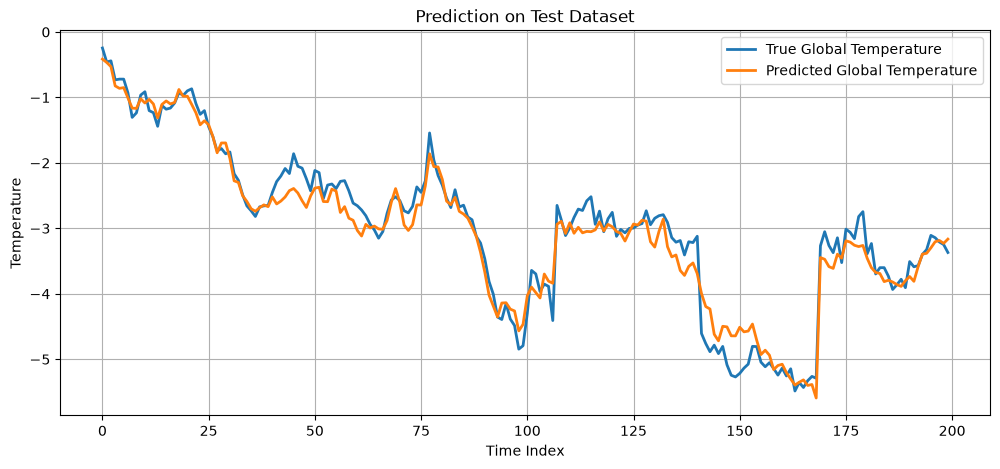

In [ ]:
results_df_sorted = results_df.sort_values(
    by=["mean_val_loss", "std_val_loss"]
)

print(results_df_sorted.head(20))

In [ ]:
results_df_sorted.to_csv(
    "conv_hyperparameter_search_results.csv",
    index=False
)

In [ ]:
best_config = results_df_sorted.iloc[0]

print("Best configuration:")
print(best_config)

In [ ]:
final_model = build_satis_model(
    conv_filters=tuple(best_config["conv_filters"]),
    kernel_size=int(best_config["kernel_size"]),
    dilation_rate=int(best_config["dilation_rate"]),
    lstm_units=int(best_config["lstm_units"]),
    dropout_rate=float(best_config["dropout_rate"]),
    learning_rate=float(best_config["learning_rate"])
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    min_delta=0.0005,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

history = final_model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)